# This script reads in the TS field from two processed atmos_fields files and plots the Nino 3.4 and DMI seasonal cycle and power spectra.


In [1]:
import netCDF4 as nc4
import glob
import intake
import os
from collections import defaultdict

import xarray as xr
import numpy as np
import pandas as pd
import math

from scipy import signal
from scipy import stats

import dask 

import xesmf as xe
import regionmask 

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.mpl
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

from matplotlib.patches import Patch

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/esmpy/__init__.py:106: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  __author__ = msg["Author"]


In [2]:
from dask.distributed import Client
client = Client(threads_per_worker=1)
#client = Client(memory_limit='4GB', n_workers=2, threads_per_worker=1)

client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/node.py:173: ResourceWarning: unclosed <socket.socket fd=61, family=2, type=1, proto=6, laddr=('0.0.0.0', 0)>
  if retries_left < 1:
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44917 instead
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprec

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/44917/status,
Dashboard: /proxy/44917/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42835,Workers: 0
Dashboard: /proxy/44917/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33073,Total threads: 1
Dashboard: /proxy/46633/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:45585,


In [3]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'
dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/scratch/{os.environ['PROJECT']}/{os.environ['USER']}/nesp/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json
Plot folder path:  /scratch/eg3/cxc548/nesp/


In [4]:
def detrend_1d(y, deg=1):
    """
    Removes polynomial trend from a 1D array while preserving the mean.

    Parameters:
        y (np.ndarray): Input 1D data array.
        deg (int): Degree of the polynomial to fit (default is 1 for linear detrending).

    Returns:
        np.ndarray: Detrended data with original mean retained.
    """
    x = np.arange(y.size) 
    z = np.polyfit(x, y, deg)  
    trend = np.polyval(z, x)  
    return y - trend + np.mean(y)  # Retain mean after detrending

def detrend_wrap(da, deg=1):
    """
    Applies 1D polynomial detrending across the 'time' dimension of an xarray DataArray.

    Parameters:
        da (xr.DataArray): Input data with a 'time' dimension.
        deg (int): Degree of the polynomial to fit (default is 1).

    Returns:
        xr.DataArray: Detrended data.
    """
    return xr.apply_ufunc(
        detrend_1d, da,
        input_core_dims=[['time']],  
        vectorize=True,  
        dask='parallelized',  
        kwargs={'deg': deg}  
    )

def detrend_monthly(da, deg=1):
    """
    Applies polynomial detrending separately to each calendar month across years.

    Parameters:
        da (xr.DataArray): Input data with 'time' dimension.
        deg (int): Degree of the polynomial to fit (default is 1).

    Returns:
        xr.DataArray: Monthly detrended data.
    """    
    return da.groupby('time.month').apply(
        lambda x: xr.apply_ufunc(
            detrend_1d, x,
            input_core_dims=[['time']],
            output_core_dims=[['time']],
            vectorize=True,
            dask='parallelized',
            output_dtypes=[float],
            kwargs={'deg': deg}
        )
    )

# def detrend_monthly(y, deg=1):
#     """
#     Detrends a 1D array by removing a polynomial fit of given degree.
#     Ignores NaN values.
#     """
#     x = np.arange(y.size)
#     mask = np.isfinite(y)  # only use valid (non-NaN) data

#     if mask.sum() <= deg:  # not enough points to fit
#         return y  # return original array

#     # Fit polynomial to valid points only
#     coeffs = np.polyfit(x[mask], y[mask], deg)
#     trend = np.polyval(coeffs, x)

#     # Subtract trend only where valid
#     y_detrended = y - trend
#     y_detrended[~mask] = np.nan  # preserve NaN positions
#     return y_detrended
    
def get_seasonal_means(da, seasons):
    """
    Computes seasonal means grouped by year for specified seasons.

    Parameters:
        da (xr.DataArray): Input data with 'time' dimension and 'season' accessor.
        seasons (list of str): List of seasons to compute (e.g., ['DJF', 'MAM']).

    Returns:
        dict: Dictionary of seasonal mean DataArrays keyed by season name.
    """
    da_season_mean = {}
    for season in seasons:
        if season == 'DJF':
            da_season_tmp = da.where(da['time.season'] == 'DJF')
            da_season = da_season_tmp.rolling(min_periods=3, center=True, time=3).mean()
            da_season_mean[season] = da_season.groupby('time.year').mean(dim='time')
        else:
            da_season = da.where(da['time.season'] == season, drop=True)
            da_season_mean[season] = da_season.groupby('time.year').mean(dim='time')
    return da_season_mean

def convert_units(da):
    """
    Converts units of an xarray DataArray to more interpretable forms.

    Supported conversions:
        - Kelvin (K) → Celsius (°C)
        - Pascal (Pa) → hectoPascal (hPa)
        - kg m-2 s-1 → mm/day

    Parameters:
        da (xr.DataArray): Input data with 'units' attribute.

    Returns:
        xr.DataArray: Data with converted units and updated metadata.
    """
    # Convert Kelvin to Celsius
    if da.attrs.get('units') == 'K':
        da = da - 273.15
        da.attrs['units'] = '°C' 
    
    # Convert Pascal to hectoPascal
    elif da.attrs.get('units') == 'Pa':
        da = da / 100.
        da.attrs['units'] = 'hPa' 

    # Convert kg m-2 s-1 to mm/day
    elif da.attrs.get('units') == 'kg m-2 s-1':
        da = da*86400.
        da.attrs['units'] = 'mm/day' 
    return da

def calcMonAnom(da):
    """
    Calculates monthly anomalies by subtracting the monthly climatology.

    Parameters:
        da (xr.DataArray): Input data with 'time' dimension.

    Returns:
        xr.DataArray: Monthly anomalies.
    """
    monclim = da.groupby('time.month').mean('time')
    monanom = da.groupby('time.month') - monclim
    return monanom 

def area_weighted_mean(da, lat_south, lat_north, lon_left, lon_right):
    """
    Computes area-weighted mean over a specified lat-lon box.

    Parameters:
        da (xr.DataArray): Input data with 'lat' and 'lon' dimensions.
        lat_south (float): Southern latitude boundary.
        lat_north (float): Northern latitude boundary.
        lon_left (float): Western longitude boundary.
        lon_right (float): Eastern longitude boundary.

    Returns:
        xr.DataArray: Area-weighted mean over the specified region.
    """
    weights = np.cos(np.deg2rad(da.lat))
    weights.name = 'weights'
    da_area_mean = da.sel(lat=slice(lat_south,lat_north),lon=slice(lon_left,lon_right)).weighted(weights).mean(('lat','lon'))
    return da_area_mean

In [5]:
def corrco_xs(a,b,dim='year',skipna=True):
    """
    Computes the Pearson correlation coefficient and its effective p-value between two xarray DataArrays.

    Parameters:
        a (xr.DataArray): First input array.
        b (xr.DataArray): Second input array.
        dim (str): Dimension over which to compute the correlation (default is 'year').
        skipna (bool): Whether to skip NaNs during computation (default is True).

    Returns:
        xr.DataArray: Concatenated result with two components along 'pearson' dimension:
            - 'correlation': Pearson correlation coefficient.
            - 'p_value': Effective p-value of the correlation.
    """
    corr = xs.pearson_r(a,b, dim=dim, skipna=skipna)
    p_value = xs.pearson_r_eff_p_value(a,b, dim=dim, skipna=skipna)
    return xr.concat([corr,p_value],dim='pearson').assign_coords({'pearson':['correlation','p_value']})

def cor_byseas_index(a,b,year1,year2):
    """
    Calculates seasonal correlation and significance between two datasets over a specified year range.

    Assumes input arrays are indexed by month (first dimension) and year (second dimension),
    and applies detrending before computing correlation.

    Parameters:
        a (xr.DataArray): First input array with dimensions [month, year].
        b (xr.DataArray): Second input array with dimensions [month, year].
        year1 (int): Start year for analysis.
        year2 (int): End year for analysis.

    Returns:
        tuple:
            - corr_byseas (np.ndarray): Array of correlation coefficients for each month (length 12).
            - sig_byseas (np.ndarray): Array of p-values for each month (length 12).
    """
    a = a.sel(year=slice(str(year1),str(year2)))
    b = b.sel(year=slice(str(year1),str(year2)))
    corr_byseas = np.zeros(12)*np.nan
    sig_byseas = np.zeros(12)*np.nan
    for i in range(0,12):
        temp = corrco_xs(detrend(a[i,:]), detrend(b[i,:]),dim='year')
        corr_byseas[i] = temp[0]
        sig_byseas[i] = temp[1]
    return corr_byseas, sig_byseas

In [6]:
def taper(n,fr=0.1,window='hanning'):
   """
   Window to taper fr/2 on both sides, with 'hanning' (default) or 'blackman' windows

    ---
    Harun Rashid
   """

   if window.lower()=='welch':
      return quadwin(n)

   nfrh = int(n*fr/2)
   t = np.ones(n,dtype=float)
   if window.lower()=='blackman':
      wnf = np.blackman(2*nfrh)
   else:
      wnf = np.hanning(2*nfrh)
   t[0:nfrh] = t[0:nfrh]*wnf[0:nfrh]
   t[-nfrh:] = t[-nfrh:]*wnf[nfrh:]
   return t
  

def smooth(x, window_len=7, window='hanning'):
    """
    Smooth the data in x using convolution with a window of requested
    size and type.

    Parameters
    ----------
    x : array_like(float)
        A flat NumPy array containing the data to smooth
    window_len : scalar(int), optional
        An odd integer giving the length of the window.  Defaults to 7.
    window : string
        A string giving the window type. Possible values are 'flat',
        'hanning', 'hamming', 'bartlett' or 'blackman'

    Returns
    -------
    array_like(float)
        The smoothed values

    Notes
    -----
    Application of the smoothing window at the top and bottom of x is
    done by reflecting x around these points to extend it sufficiently
    in each direction.

    This function is faster than pd.rolling() (2.35 times). Also, this doesn't loose
    data at both ends (because of convolution).

   Harun Rashid
    """
    if len(x) < window_len:
        raise ValueError("Input vector length must be >= window length.")

    if window_len < 3:
        raise ValueError("Window length must be at least 3.")

    if not window_len % 2:  # window_len is even
        window_len += 1
        print("Window length reset to {}".format(window_len))

    windows = {'hanning': np.hanning,
               'hamming': np.hamming,
               'bartlett': np.bartlett,
               'blackman': np.blackman,
               'flat': np.ones  # moving average
               }

    # === Reflect x around x[0] and x[-1] prior to convolution === #
    k = int(window_len / 2)
    xb = x[:k]   # First k elements
    xt = x[-k:]  # Last k elements
    s = np.concatenate((xb[::-1], x, xt[::-1]))

    # === Select window values === #
    if window in windows.keys():
        w = windows[window](window_len)
    else:
        msg = "Unrecognized window type '{}'".format(window)
        print(msg + " Defaulting to hanning")
        w = windows['hanning'](window_len)

    return np.convolve(w / w.sum(), s, mode='valid')

def spectrum(x0, window_len=11, window='hanning'):
#def periodogram(x, window=None, window_len=7):
    r"""
    Computes the periodogram

    .. math::

        I(w) = \frac{1}{n} \Big[ \sum_{t=0}^{n-1} x_t e^{itw} \Big] ^2

    at the Fourier frequences :math:`w_j := \frac{2 \pi j}{n}`,
    :math:`j = 0, \dots, n - 1`, using the fast Fourier transform. Only the
    frequences :math:`w_j` in :math:`[0, \pi]` and corresponding values
    :math:`I(w_j)` are returned. If a window type is given then smoothing
    is performed.

    Parameters
    ----------
    x : 1-d array_like(float)
        A flat NumPy array containing the data to analyse
    window : string
        A string giving the window type. Possible values are 'flat',
        'hanning' (default), 'hamming', 'bartlett' or 'blackman'
    window_len : scalar(int), optional(default=11)
        An odd integer giving the length of the window.  Defaults to 11.

    Returns
    -------
    w : array_like(float)
        Fourier frequences at which spectrum is evaluated
    I_w : array_like(float)
        Values of spectrum at the Fourier frequences

    ---
    Harun Rashid
    """
    n = len(x0)
    #if dtrend in [1,2]:
    #   h_detrended = detrend(x,dtrend)
    #else:
    #   h_detrended = h
    varx0 = x0.var() #variance
    winweights = taper(n,0.1)
    x = x0 * winweights
    I_w = np.abs(np.fft.fft(x))**2 / n
    #w = 2 * np.pi * np.arange(n) / n  # Fourier frequencies
    w = np.arange(n) / n  # Fourier frequencies (I changed to linear freqs)
    w, I_w = w[:int(n/2)+1], I_w[:int(n/2)+1]  # Take only values on [0, pi]
    if window:
        I_w = smooth(I_w, window_len=window_len, window=window)
    spec_vals = 2*I_w*varx0.values/((x.var()).values)       # multiplying by 2 keeps the observed variance
    if isinstance(x,pd.Series):
        return pd.Series(spec_vals,index=w)
    else:
        return w, spec_vals

In [7]:
def split_into_centuries(da, start_year=None, chunk_size=100):
    """
    Splits an xarray DataArray into century-sized chunks.

    Parameters:
        da (xr.DataArray): Input data with a 'time' coordinate.
        start_year (int, optional): Starting year for chunking. If None, inferred from data.
        chunk_size (int): Number of years per chunk (default is 100).

    Returns:
        list of xr.DataArray: List of century-sized chunks.
    """
    if start_year is None:
        start_year = int(da.time.dt.year.min().item())
    end_year = int(da.time.dt.year.max().item())

    chunks = []
    for y0 in range(start_year, end_year + 1, chunk_size):
        y1 = y0 + chunk_size - 1
        chunk = da.sel(time=slice(f'{y0}-01-01', f'{y1}-12-31'))
        if chunk.size > 0:
            chunks.append(chunk)

    return chunks

# Read in data

In [8]:
import warnings
warnings.filterwarnings('ignore')


#datastore_path = "/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json"
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

In [9]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [10]:
datastore_filtered = datastore.search(realm="atmos", frequency="1mon")

for col in COLUMNS_WITH_ITERABLES:
    datastore_filtered.df[col] = datastore_filtered.df[col].astype("object").map(lambda x: list(map(str, x)))

df = available_variables(datastore_filtered)
df.index

Index(['fld_s00i004', 'fld_s00i010', 'fld_s00i012', 'fld_s00i023',
       'fld_s00i024', 'fld_s00i025', 'fld_s00i028', 'fld_s00i029',
       'fld_s00i031', 'fld_s00i032',
       ...
       'rho_level_height', 'sigma_rho', 'sigma_theta', 'sigma_theta_0',
       'sigma_theta_1', 'sigma_theta_2', 'theta_level_height',
       'theta_level_height_0', 'theta_level_height_1', 'theta_level_height_2'],
      dtype='object', name='variable', length=245)

In [11]:
%%time


ts_ds = datastore.search(variable="fld_s00i024", frequency="1mon")
    
ts = ts_ds.to_dask(
    xarray_open_kwargs={
        "chunks": "auto",
   },
    xarray_combine_by_coords_kwargs={
        'compat' : 'override',
        'data_vars': 'minimal',
        'coords': 'minimal'
    })


#test_run = xr.open_dataset("/g/data/eg3/cxc548/nesp/ACCESS_testing/atmos_fields_cm3_1981-2030.nc",decode_times=True).ts
test_run_ts = convert_units(ts['fld_s00i024']).chunk({'time': -1})#, 'lat': 36, 'lon': 64}) #degC
run1label = "CM3"

CPU times: user 33.3 s, sys: 8.42 s, total: 41.7 s
Wall time: 3min 5s


In [12]:
## read in last 200  yrs of CM2
#CM2
cm2_dir = "/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/atm/netCDF/"

#cm2_ts_xr = xr.open_mfdataset(cm2_dir+"*pm000*mon.nc",concat_dim="time",combine="nested").fld_s00i024 #, 'lat': 36, 'lon': 64})
cm2_ts_xr = xr.open_dataset("/g/data/eg3/cxc548/nesp/ACCESS_testing/atmos_fields_cm225km_001-141.nc",decode_times=True).ts
cm2_ts = convert_units(cm2_ts_xr).chunk({'time': -1})

# read in obs (1870-2021)
obs_ts_xr = xr.open_dataset("/g/data/ct11/access-nri/replicas/esmvaltool/obsdata-v2/Tier2/HadISST/OBS_HadISST_reanaly_1_Amon_ts_187001-202112.nc",decode_times=True).ts
obs_ts = convert_units(obs_ts_xr).chunk({'time': -1})
#obs_ts = obs_ts.sel(time=slice('1950','2021'))

In [13]:
'''
import os
import glob
import xarray as xr
import xesmf as xe
import numpy as np

    
ds = cm2_sst

target_grid = xr.Dataset({
    'lat': (['lat'], np.arange(-90, 91, 1)),
    'lon': (['lon'], np.arange(0, 360, 1))
})

regridder = xe.Regridder(ds, target_grid, 'bilinear', periodic=True)
regridded_cm2_sst = regridder(ds)
regridded_cm2_sst.to_netcdf("/scratch/eg3/zg0866/tos_Omon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_0900-1100_regridded.nc")
'''

'\nimport os\nimport glob\nimport xarray as xr\nimport xesmf as xe\nimport numpy as np\n\n    \nds = cm2_sst\n\ntarget_grid = xr.Dataset({\n    \'lat\': ([\'lat\'], np.arange(-90, 91, 1)),\n    \'lon\': ([\'lon\'], np.arange(0, 360, 1))\n})\n\nregridder = xe.Regridder(ds, target_grid, \'bilinear\', periodic=True)\nregridded_cm2_sst = regridder(ds)\nregridded_cm2_sst.to_netcdf("/scratch/eg3/zg0866/tos_Omon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_0900-1100_regridded.nc")\n'

In [14]:
#print(obs_ts.data)

# calculate monthly anomalies

In [15]:
test_run_ts_monanom = calcMonAnom(test_run_ts)
test_run_ts_monanom = test_run_ts_monanom.chunk({'time': -1})
cm2_ts_monanom = calcMonAnom(cm2_ts)
cm2_ts_monanom = cm2_ts_monanom.chunk({'time': -1})

test_run_ts_monanom_dt = detrend_monthly(test_run_ts_monanom, deg=1)

cm2_ts_monanom_dt = detrend_monthly(cm2_ts_monanom, deg=1)

obs_monanom = calcMonAnom(obs_ts)
obs_monanom = obs_monanom.chunk({'time': -1})

obs_monanom_dt = detrend_monthly(obs_monanom, deg=1)

# calculate Nino3.4 index

In [16]:
test_run_nino34 = area_weighted_mean(test_run_ts_monanom_dt, lat_south=-5, lat_north=5, lon_left=190, lon_right=240).compute()
cm2_nino34 = area_weighted_mean(cm2_ts_monanom_dt, lat_south=-5, lat_north=5, lon_left=190, lon_right=240).compute()
obs_nino34 = area_weighted_mean(obs_monanom_dt, lat_south=-5, lat_north=5, lon_left=190, lon_right=240).compute()

# calculate DMI

In [17]:
test_run_dmi = (area_weighted_mean(test_run_ts_monanom_dt, lat_south=-10, lat_north=10, lon_left=50, lon_right=70) - area_weighted_mean(test_run_ts_monanom_dt, lat_south=-10, lat_north=0, lon_left=90, lon_right=110)).compute()

cm2_dmi = (area_weighted_mean(cm2_ts_monanom_dt, lat_south=-10, lat_north=10, lon_left=50, lon_right=70) - area_weighted_mean(cm2_ts_monanom_dt, lat_south=-10, lat_north=0, lon_left=90, lon_right=110)).compute()
obs_dmi = (area_weighted_mean(obs_monanom_dt, lat_south=-10, lat_north=10, lon_left=50, lon_right=70) - area_weighted_mean(obs_monanom_dt, lat_south=-10, lat_north=0, lon_left=90, lon_right=110)).compute()


# calculate seasonal cycle of Nino3.4 and DMI

In [18]:
test_run_nino34_monstd = test_run_nino34.groupby('time.month').std('time')

cm2_nino34_monstd = cm2_nino34.groupby('time.month').std('time')
obs_nino34_monstd = obs_nino34.groupby('time.month').std('time')

test_run_dmi_monstd = test_run_dmi.groupby('time.month').std('time')

cm2_dmi_monstd = cm2_dmi.groupby('time.month').std('time')

obs_dmi_monstd = obs_dmi.groupby('time.month').std('time')

In [19]:
print(obs_dmi.data)

[-0.02117112  0.04387131  0.51956026 ... -0.03922338  0.05456875
 -0.14948792]


# plot output

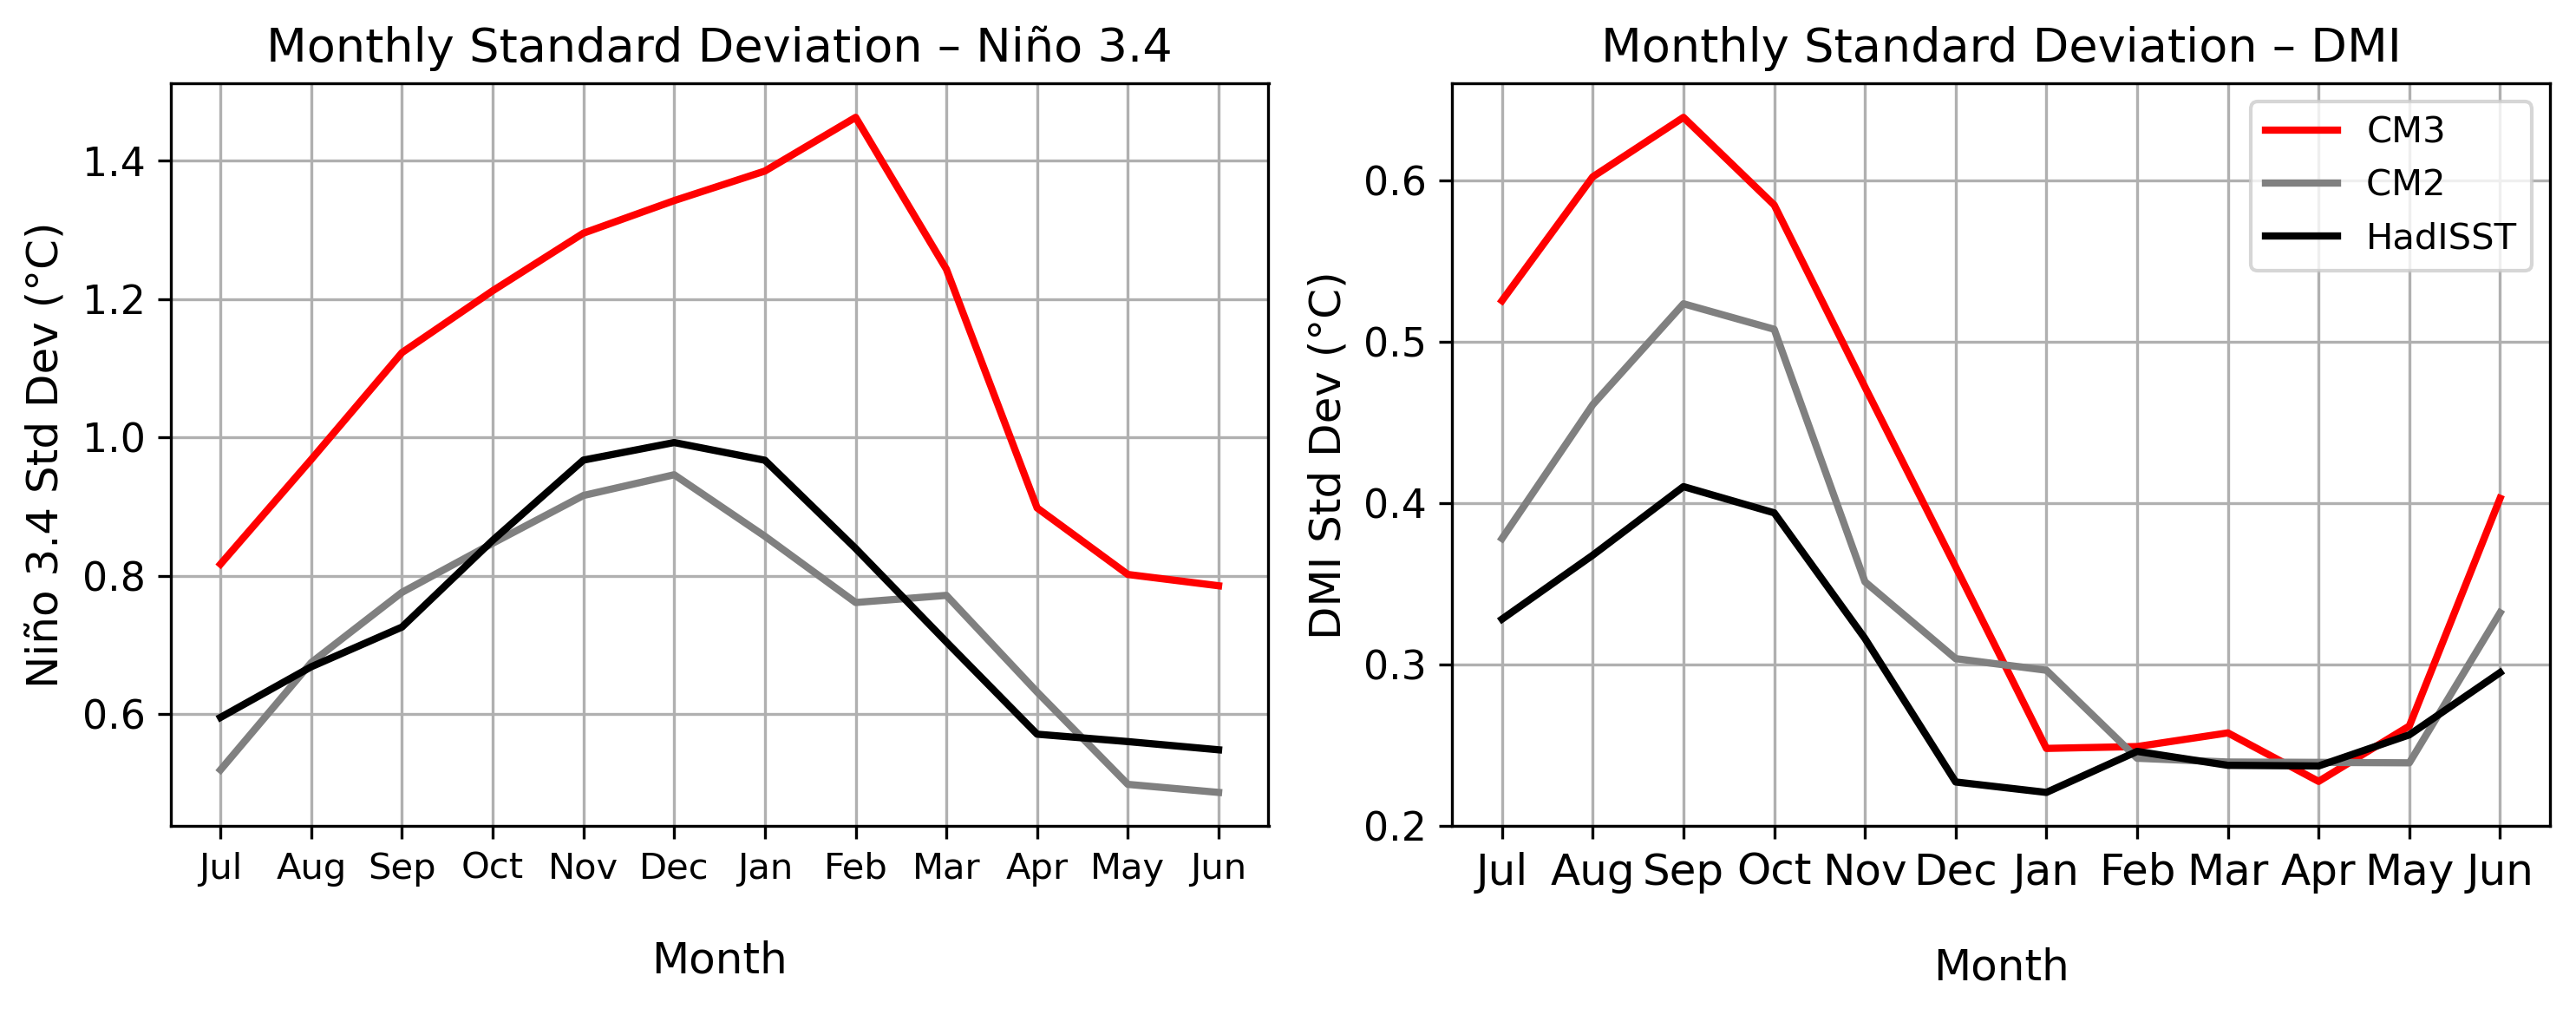

<Figure size 1920x1440 with 0 Axes>

In [20]:

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# Panel 1: Niño 3.4
ax1 = axs[0]
test_run_nino34_monstd.roll(month=-6).plot(ax=ax1, color='red', label=run1label, linewidth=2)
cm2_nino34_monstd.roll(month=-6).plot(ax=ax1, color='grey', label='CM2 ', linewidth=2)
obs_nino34_monstd.roll(month=-6).plot(ax=ax1, color='black', label='obs_ts (1979–2022)', linewidth=2)

ax1.set_ylabel('Niño 3.4 Std Dev (°C)', fontsize=12)
ax1.set_title('Monthly Standard Deviation – Niño 3.4', fontsize=13)
ax1.set_xlabel('Month', labelpad=15, fontsize=12)
ax1.grid(True)
#ax1.legend(fontsize=10, loc='upper right')
ax1.tick_params(axis='y', labelsize=11)

# Panel 2: DMI
ax2 = axs[1]
test_run_dmi_monstd.roll(month=-6).plot(ax=ax2, color='red', label=run1label, linewidth=2)
cm2_dmi_monstd.roll(month=-6).plot(ax=ax2, color='grey', label='CM2 ', linewidth=2)
obs_dmi_monstd.roll(month=-6).plot(ax=ax2, color='black', label='HadISST', linewidth=2)

ax2.set_ylabel('DMI Std Dev (°C)', fontsize=12)
ax2.set_title('Monthly Standard Deviation – DMI', fontsize=13)
ax2.set_xticks(np.arange(1, 13))
ax2.set_xticklabels(['Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'], fontsize=12)
ax2.set_xlabel('Month', labelpad=15, fontsize=12)
ax2.grid(True)
ax2.legend(fontsize=10, loc='upper right')
ax2.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()
plt.savefig(plotfolder+"cm3_n34_dmi_stddev.png", bbox_inches="tight", dpi=500)

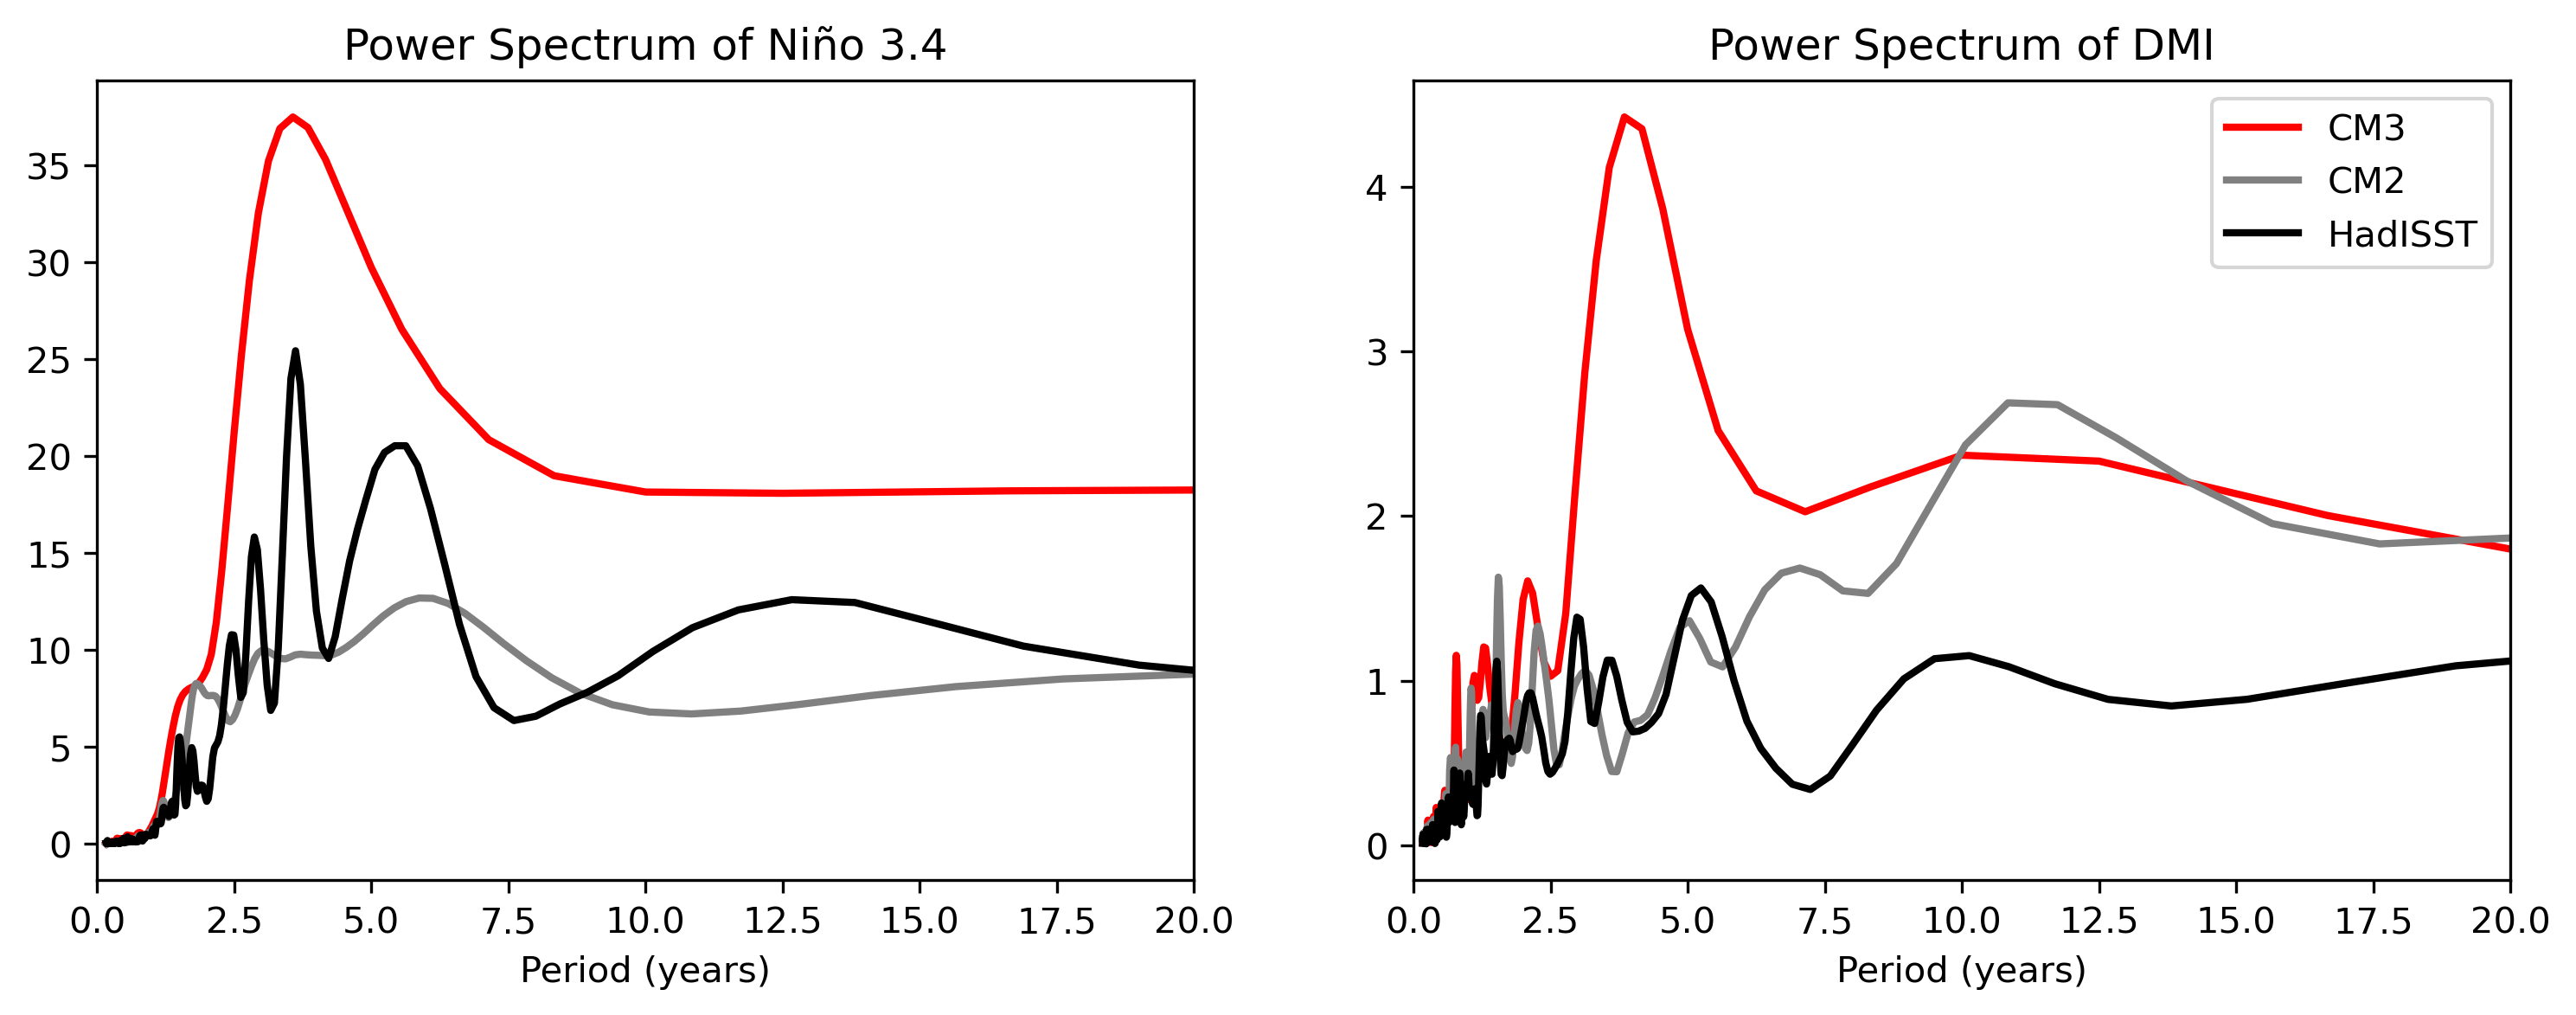

In [25]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Panel 1: Niño 3.4
ax1 = axs[0]
test_run_anom = test_run_nino34
n34_freq_test_run, n34_fft_test_run = spectrum(xr.DataArray(test_run_anom.data), window_len=21, window='hanning')
n34_freq_test_run = 12 * n34_freq_test_run
ax1.plot(1 / n34_freq_test_run, n34_fft_test_run, linewidth=2, color='red', label=run1label)

cm2_anom = cm2_nino34
n34_freq_cm2, n34_fft_cm2 = spectrum(xr.DataArray(cm2_anom.data), window_len=21, window='hanning')
n34_freq_cm2 = 12 * n34_freq_cm2
ax1.plot(1 / n34_freq_cm2, n34_fft_cm2, linewidth=2, color='grey', label='CM2')

obs_anom = obs_nino34
n34_freq_obs, n34_fft_obs = spectrum(xr.DataArray(obs_anom.data), window_len=11, window='hanning')
n34_freq_obs = 12 * n34_freq_obs
ax1.plot(1 / n34_freq_obs, n34_fft_obs, linewidth=2, color='black', label='HadISST')

ax1.set_xlim(0, 20)
ax1.set_xlabel('Period (years)')
ax1.set_title('Power Spectrum of Niño 3.4')

# Panel 2: DMI
ax2 = axs[1]

test_run_anom = test_run_dmi
dmi_freq_test_run, dmi_fft_test_run = spectrum(xr.DataArray(test_run_anom.data), window_len=11, window='hanning')
dmi_freq_test_run = 12 * dmi_freq_test_run
ax2.plot(1 / dmi_freq_test_run, dmi_fft_test_run, linewidth=2, color='red', label=run1label)

cm2_anom = cm2_dmi
dmi_freq_cm2, dmi_fft_cm2 = spectrum(xr.DataArray(cm2_anom.data), window_len=11, window='hanning')
dmi_freq_cm2 = 12 * dmi_freq_cm2
ax2.plot(1 / dmi_freq_cm2, dmi_fft_cm2, linewidth=2, color='grey', label='CM2')

obs_anom = obs_dmi
dmi_freq_obs, dmi_fft_obs = spectrum(xr.DataArray(obs_anom.data), window_len=11, window='hanning')
dmi_freq_obs = 12 * dmi_freq_obs
ax2.plot(1 / dmi_freq_obs, dmi_fft_obs, linewidth=2, color='black', label='HadISST')

# You can replicate the same structure here for DMI or any other dataset
ax2.set_xlim(0, 20)
ax2.set_xlabel('Period (years)')
ax2.set_title('Power Spectrum of DMI')  # Update title and data accordingly
ax2.legend()
plt.savefig(plotfolder+"cm3_n34_dmi_powerspectra.png", bbox_inches="tight", dpi=500)

In [22]:
# #split into 100 year chunks

# run1_n34_century_chunks = split_into_centuries(test_run_nino34)
# run1_dmi_century_chunks = split_into_centuries(test_run_dmi)


In [23]:
# #plot n34 for each century

# fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# # Panel 1: Niño 3.4
# ax1 = axs[0]
# for i, chunk in enumerate(run1_n34_century_chunks):
#     test_run_anom = chunk
#     n34_freq_test_run, n34_fft_test_run = spectrum(xr.DataArray(test_run_anom.data), window_len=13, window='hanning')
#     n34_freq_test_run = 12 * n34_freq_test_run
#     ax1.plot(1 / n34_freq_test_run, n34_fft_test_run, linewidth=2, label=run1label+" century "+str(i+1))

# # Panel 1: Niño 3.4
# ax2 = axs[1]
# for i, chunk in enumerate(run2_n34_century_chunks):
#     test_run_anom = chunk
#     n34_freq_test_run, n34_fft_test_run = spectrum(xr.DataArray(test_run_anom.data), window_len=13, window='hanning')
#     n34_freq_test_run = 12 * n34_freq_test_run
#     ax2.plot(1 / n34_freq_test_run, n34_fft_test_run, linewidth=2, label=run2label+" century "+str(i+1))

# ax1.set_xlim(0, 13)
# ax1.set_xlabel('Period (years)')
# ax1.set_title('Power Spectrum of Niño 3.4')
# ax1.legend(fontsize=8)
# ax2.set_xlim(0, 13)
# ax2.set_xlabel('Period (years)')
# ax2.set_title('Power Spectrum of Niño 3.4')
# ax2.legend(fontsize=8)

In [24]:
# #plot DMI for each century

# fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# # Panel 1: Niño 3.4
# ax1 = axs[0]
# for i, chunk in enumerate(run1_dmi_century_chunks):
#     test_run_anom = chunk
#     dmi_freq_test_run, dmi_fft_test_run = spectrum(xr.DataArray(test_run_anom.data), window_len=13, window='hanning')
#     dmi_freq_test_run = 12 * dmi_freq_test_run
#     ax1.plot(1 / dmi_freq_test_run, dmi_fft_test_run, linewidth=2, label=run1label+" century "+str(i+1))

# # Panel 1: Niño 3.4
# ax2 = axs[1]
# for i, chunk in enumerate(run2_dmi_century_chunks):
#     test_run_anom = chunk
#     dmi_freq_test_run, dmi_fft_test_run = spectrum(xr.DataArray(test_run_anom.data), window_len=13, window='hanning')
#     dmi_freq_test_run = 12 * dmi_freq_test_run
#     ax2.plot(1 / dmi_freq_test_run, dmi_fft_test_run, linewidth=2, label=run2label+" century "+str(i+1))

# ax1.set_xlim(0, 13)
# ax1.set_xlabel('Period (years)')
# ax1.set_title('Power Spectrum of DMI')
# ax1.legend(fontsize=8)
# ax2.set_xlim(0, 13)
# ax2.set_xlabel('Period (years)')
# ax2.set_title('Power Spectrum of DMI')
# ax2.legend(fontsize=8)